# Project Title: COVID Symptom Checker

**Goal:** Build a Decision Tree Classification model to predict whether a patient is likely `COVID_Positive` based on synthetic symptom data (`Fever`, `Cough`, `Loss_of_Taste_Smell`, etc.).
This notebook includes handling missing values, treating outliers, evaluating feature importance, and visualizing the actual Decision Tree.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Data Loading

In [2]:
df = pd.read_csv('covid_symptom_data.csv')
print('Shape:', df.shape)
display(df.head())

Shape: (4000, 7)


,Age,Fever_F,Cough,Fatigue,Loss_of_Taste_Smell,Breathing_Difficulty,COVID_Positive
0,38.0,98.2,1,0,0,0,0
1,41.0,97.7,0,0,0,0,0
2,46.0,99.5,0,1,1,0,0
3,39.0,99.3,1,1,0,0,0
4,88.0,98.5,0,1,0,0,0


## 2. Checking and Treating Null Values

In [3]:
print("Null values BEFORE treatment:\n")
print(df.isnull().sum())

# Impute missing continuous values with the median
for col in ['Age', 'Fever_F']:
    df[col].fillna(df[col].median(), inplace=True)

print("\nNull values AFTER treatment:\n")
print(df.isnull().sum())

Null values BEFORE treatment:

Age                      80
Fever_F                 119
Cough                     0
Fatigue                   0
Loss_of_Taste_Smell       0
Breathing_Difficulty      0
COVID_Positive            0
dtype: int64

Null values AFTER treatment:

Age                     0
Fever_F                 0
Cough                   0
Fatigue                 0
Loss_of_Taste_Smell     0
Breathing_Difficulty    0
COVID_Positive          0
dtype: int64


/tmp/ipykernel_3376/1738610043.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## 3. Visualizing and Treating Outliers

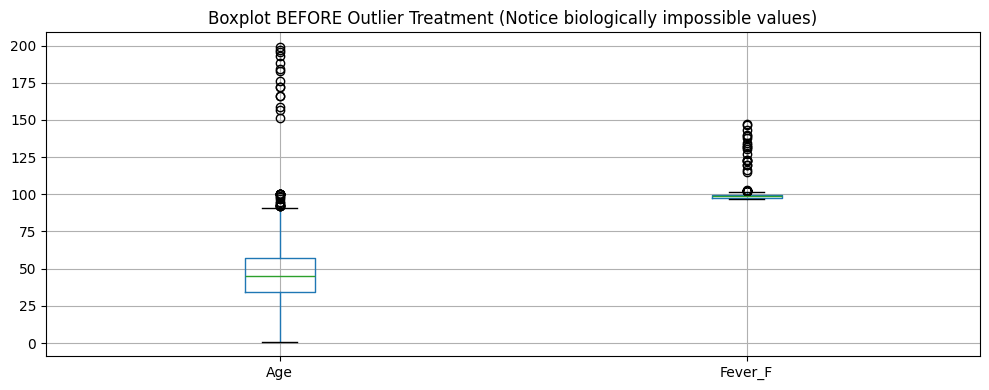

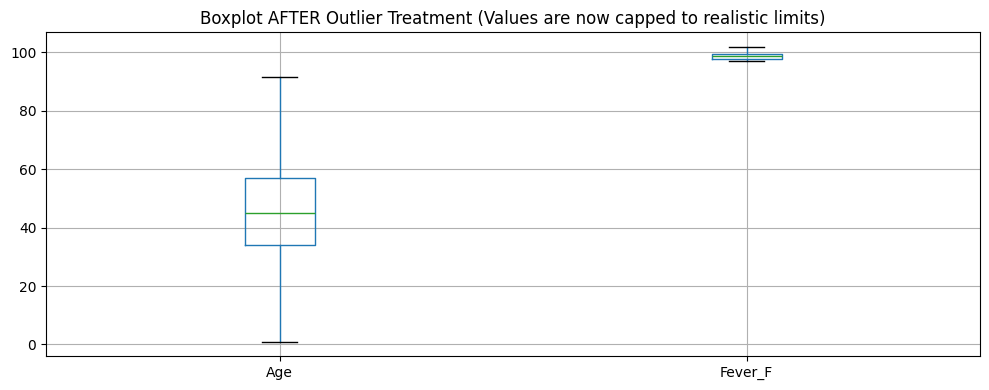

In [4]:
num_cols = ['Age', 'Fever_F']

# Plotting BEFORE Outlier Treatment
plt.figure(figsize=(10, 4))
df[num_cols].boxplot(rot=0)
plt.title('Boxplot BEFORE Outlier Treatment (Notice biologically impossible values)')
plt.tight_layout()
plt.show()

# Outlier Treatment using IQR Method
def clip_outliers(dataframe, col):
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[col] = np.clip(dataframe[col], lower_bound, upper_bound)
    return dataframe

for col in num_cols:
    df = clip_outliers(df, col)

# Plotting AFTER Outlier Treatment
plt.figure(figsize=(10, 4))
df[num_cols].boxplot(rot=0)
plt.title('Boxplot AFTER Outlier Treatment (Values are now capped to realistic limits)')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis & Correlation

/tmp/ipykernel_3376/3220626106.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='COVID_Positive', data=df, palette='Set2')


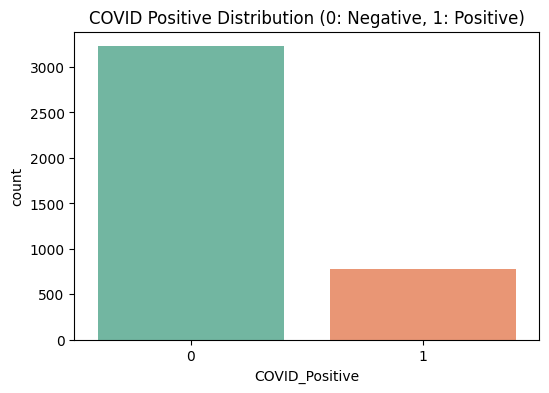

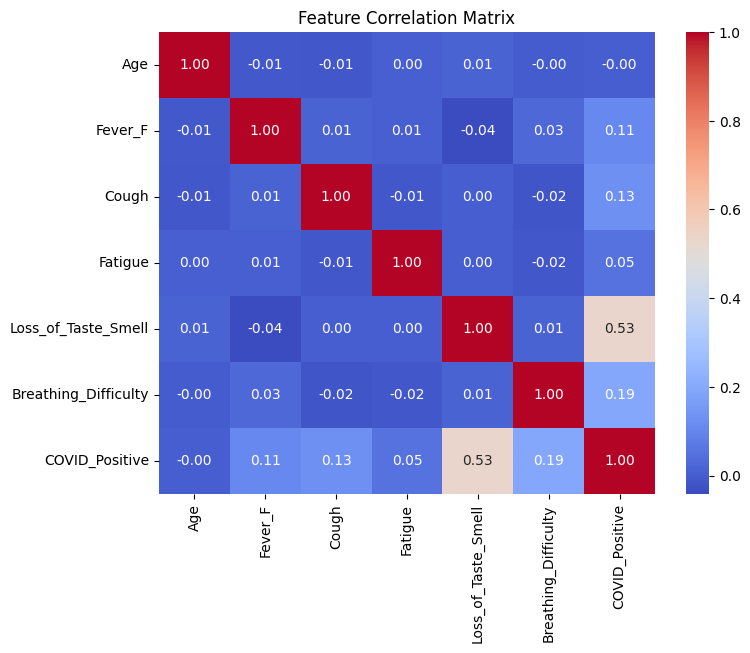

In [5]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='COVID_Positive', data=df, palette='Set2')
plt.title('COVID Positive Distribution (0: Negative, 1: Positive)')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 5. Feature Split & Model Training (Decision Tree)

In [6]:
X = df.drop(columns=['COVID_Positive'])
y = df['COVID_Positive']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape}')
print(f'Test size : {X_test.shape}')

# Train Decision Tree Classifier
# max_depth=4 to prevent overfitting and keep the tree readable
model = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
model.fit(X_train, Y_train)

Train size: (3200, 6)
Test size : (800, 6)


DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)

## 6. Model Evaluation

Accuracy Score: 85.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       646
           1       0.60      0.75      0.67       154

    accuracy                           0.86       800
   macro avg       0.77      0.82      0.79       800
weighted avg       0.87      0.86      0.86       800



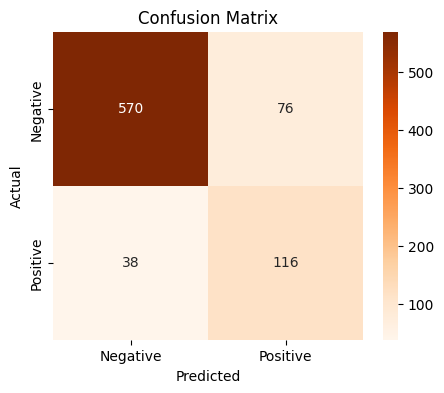

In [7]:
Y_pred = model.predict(X_test)
acc = accuracy_score(Y_test, Y_pred)

print(f'Accuracy Score: {acc*100:.2f}%\n')
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Feature Importance & Tree Visualization

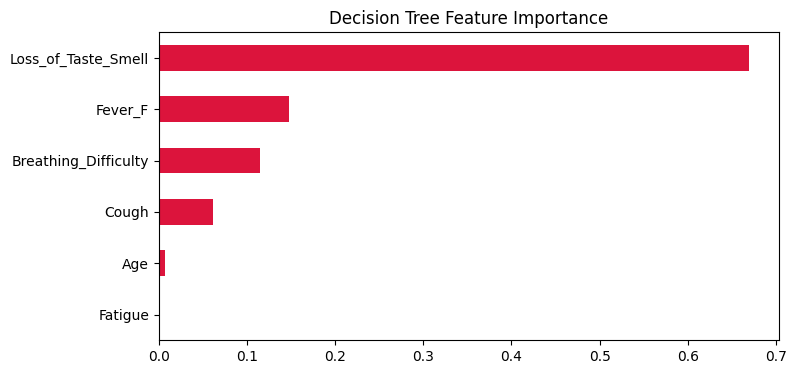

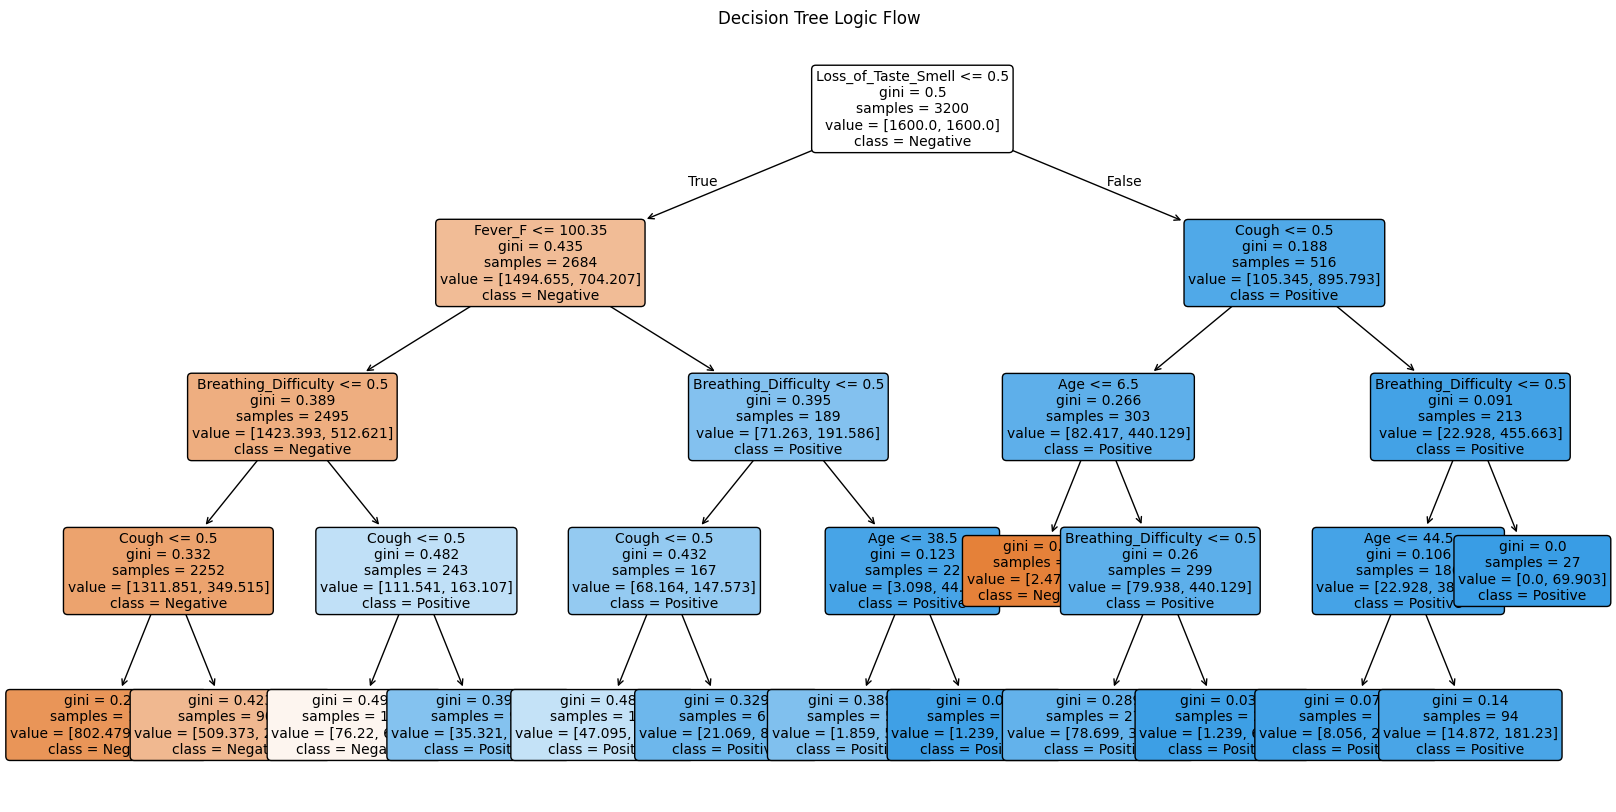

In [8]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', color='crimson', figsize=(8, 4))
plt.title('Decision Tree Feature Importance')
plt.show()

# Visualize the actual Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Negative', 'Positive'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Logic Flow")
plt.show()